# Predicting Air Jordan Resale Price: A Regression Model

**Author:** Darius Follins
**Dataset:** [Jordan Market Dataset 2026](https://www.kaggle.com/datasets/abdullahmeo/air-jordan-sneaker-market-and-resale-data2023-2026/data) (synthetic, 5,000 transactions, 2023–2025) — Kaggle

## Overview

This is the modeling follow-up to [`jordan_resale_eda.ipynb`](jordan_resale_eda.ipynb), which cleaned
and explored this dataset. The EDA found that:

- `Condition` is the dominant driver of resale margin (Deadstock ≫ VNDS ≫ Used)
- `Shoe_Model` and `Colorway` have smaller but real effects
- `Days_in_Inventory` is essentially uncorrelated with price
- There's no meaningful time trend across 2023–2025

Here we turn those findings into a predictive model for `Resale_Price_USD`: a linear baseline, a tuned
Random Forest, and a Gradient Boosting model, checking whether the feature importances each one learns
line up with what the EDA already suggested.

**Goals:**
1. Engineer features and make explicit modeling decisions (what's fair game to use, what's leakage)
2. Split the data by time, not randomly, to simulate predicting future sales from past ones
3. Fit a linear regression baseline
4. Fit a Random Forest, then tune it with cross-validated grid search
5. Fit a Gradient Boosting model for comparison
6. Evaluate every model against naive baselines and against each other
7. Inspect feature importances across model types and importance methods


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42


## 1. Load Data & Engineer Features


In [2]:
df = pd.read_csv("jordan_market_dataset_2026.csv")
df["Sale_Date"] = pd.to_datetime(df["Sale_Date"])
df["Sale_Quarter"] = df["Sale_Date"].dt.quarter
df["Sale_Year"] = df["Sale_Date"].dt.year

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()


Shape: 5,000 rows x 12 columns


,Transaction_ID,Sale_Date,Shoe_Model,Colorway,Condition,Retail_Price_USD,Resale_Price_USD,Sales_Channel,Days_in_Inventory,Profit_Margin_USD,Sale_Quarter,Sale_Year
0,TRX-100001,2024-10-23,Air Jordan 11 Retro,Sail,Used,225,194.67,GOAT,13,-30.33,4,2024
1,TRX-100002,2023-10-23,Air Jordan 1 High,Mocha,Deadstock (Brand New),185,230.46,StockX,10,45.46,4,2023
2,TRX-100003,2023-11-13,Air Jordan 4 Retro,Concord,Deadstock (Brand New),212,270.37,kick hub 2026,33,58.37,4,2023
3,TRX-100004,2024-02-01,Air Jordan 4 Retro,Mocha,Used,223,180.43,Stadium Goods,60,-42.57,1,2024
4,TRX-100005,2023-05-29,Air Jordan 1 Low,Mocha,Used,137,117.43,kick hub 2026,30,-19.57,2,2023


### Which features are we allowed to use?

Not every column in the dataset is fair to feed into a model that predicts price **at the time a shoe
is listed for sale**. Three columns need a deliberate decision:

- **`Days_in_Inventory` — excluded.** This is only known *after* the sale finally happens (it's how
  long the shoe took to sell). Using it to predict `Resale_Price_USD` would be leakage — in a real
  deployment, you would not have this number yet when you need the prediction. The EDA also found it's
  essentially uncorrelated with price anyway, so we lose little by dropping it.
- **`Retail_Price_USD` — included.** This is known before the shoe is ever listed (it's the original
  MSRP), so it's a legitimate predictor.
- **`Sale_Date` itself — replaced with `Sale_Year`/`Sale_Quarter`.** The exact date is too granular and
  guarantees no overlap between train/test; year and quarter let the model use coarser time information
  without that problem. The EDA found no real trend here, so we don't expect much from these features,
  but we test them rather than assuming.

**Features used:** `Shoe_Model`, `Colorway`, `Condition`, `Sales_Channel`, `Retail_Price_USD`,
`Sale_Year`, `Sale_Quarter`
**Target:** `Resale_Price_USD`
**Dropped:** `Transaction_ID` (identifier only), `Days_in_Inventory` (leakage), `Profit_Margin_USD`
(derived directly from the target — including it would make the problem trivial and is a second form of
leakage), `Sale_Date` (replaced by year/quarter)


In [3]:
FEATURES_CAT = ["Shoe_Model", "Colorway", "Condition", "Sales_Channel"]
FEATURES_NUM = ["Retail_Price_USD", "Sale_Year", "Sale_Quarter"]
TARGET = "Resale_Price_USD"

model_df = df[FEATURES_CAT + FEATURES_NUM + [TARGET, "Sale_Date"]].copy()
model_df.head()


,Shoe_Model,Colorway,Condition,Sales_Channel,Retail_Price_USD,Sale_Year,Sale_Quarter,Resale_Price_USD,Sale_Date
0,Air Jordan 11 Retro,Sail,Used,GOAT,225,2024,4,194.67,2024-10-23
1,Air Jordan 1 High,Mocha,Deadstock (Brand New),StockX,185,2023,4,230.46,2023-10-23
2,Air Jordan 4 Retro,Concord,Deadstock (Brand New),kick hub 2026,212,2023,4,270.37,2023-11-13
3,Air Jordan 4 Retro,Mocha,Used,Stadium Goods,223,2024,1,180.43,2024-02-01
4,Air Jordan 1 Low,Mocha,Used,kick hub 2026,137,2023,2,117.43,2023-05-29


## 2. Train/Test Split — By Time, Not Randomly

A random split would let the model "see" sales from every period during training, which overstates how
well it would really do predicting *future* sales it's never seen. Instead we train on **2023–2024** and
test on **2025** — a more honest simulation of real deployment.


In [4]:
train_df = model_df[model_df["Sale_Date"] < "2025-01-01"].drop(columns="Sale_Date")
test_df = model_df[model_df["Sale_Date"] >= "2025-01-01"].drop(columns="Sale_Date")

X_train, y_train = train_df[FEATURES_CAT + FEATURES_NUM], train_df[TARGET]
X_test, y_test = test_df[FEATURES_CAT + FEATURES_NUM], test_df[TARGET]

print(f"Train: {len(X_train):,} rows (2023-2024)")
print(f"Test:  {len(X_test):,} rows (2025)")

# Confirm no categories appear in test that the model never saw in training
for c in FEATURES_CAT:
    unseen = set(X_test[c].unique()) - set(X_train[c].unique())
    if unseen:
        print(f"WARNING - unseen categories in {c}: {unseen}")
print("No unseen-category warnings above means every test category was present in training.")


Train: 3,729 rows (2023-2024)
Test:  1,271 rows (2025)
No unseen-category warnings above means every test category was present in training.


## 3. Baseline: How Good Is 'Just Guess'?

Before trusting any model, we need a floor to beat. Two naive baselines:
1. **Predict the training-set mean resale price** for every test row
2. **Predict the retail price** (i.e. assume the shoe resells at exactly MSRP)


In [5]:
def evaluate(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{label:28s}  MAE: ${mae:7.2f}   RMSE: ${rmse:7.2f}   R2: {r2:6.3f}")
    return {"label": label, "MAE": mae, "RMSE": rmse, "R2": r2}

results = []

mean_pred = np.full_like(y_test, y_train.mean(), dtype=float)
results.append(evaluate(y_test, mean_pred, "Baseline: train mean"))

retail_pred = X_test["Retail_Price_USD"].values
results.append(evaluate(y_test, retail_pred, "Baseline: predict MSRP"))


Baseline: train mean          MAE: $ 129.69   RMSE: $ 166.81   R2: -0.000
Baseline: predict MSRP        MAE: $ 120.73   RMSE: $ 178.90   R2: -0.150


## 4. Linear Regression Baseline

A one-hot encoded linear model — interpretable, and a reasonable "first real model" benchmark.


In [6]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), FEATURES_CAT),
    ],
    remainder="passthrough"
)

linear_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", LinearRegression())
])

linear_pipeline.fit(X_train, y_train)
linear_pred = linear_pipeline.predict(X_test)
results.append(evaluate(y_test, linear_pred, "Linear Regression"))


Linear Regression             MAE: $  62.07   RMSE: $  88.37   R2:  0.719


## 5. Random Forest

A tree-based model can capture interactions (e.g. Condition x Model) that a linear model can't, without
us having to hand-engineer interaction terms.


In [7]:
rf_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestRegressor(n_estimators=300, max_depth=8, random_state=RANDOM_STATE, n_jobs=-1))
])

rf_pipeline.fit(X_train, y_train)
rf_pred = rf_pipeline.predict(X_test)
results.append(evaluate(y_test, rf_pred, "Random Forest (default)"))


Random Forest (default)       MAE: $  57.52   RMSE: $  85.73   R2:  0.736


## 6. Hyperparameter Tuning with Cross-Validation

The Random Forest above used fixed, hand-picked settings (`n_estimators=300, max_depth=8`). Instead of
guessing, we can search over a grid of settings and let **cross-validation** pick the best one
objectively.

**What cross-validation means here:** we split the *training set only* (2023–2024, never touching the
2025 test set) into 3 folds. For each candidate combination of settings, we train on 2 folds and
validate on the 3rd, rotate which fold is held out, and average the error across all 3 rotations. This
gives a more reliable estimate of a setting's quality than a single train/validation split would,
because every training row gets used for validation exactly once.

We search over:
- `n_estimators` (how many trees): 100 or 200
- `max_depth` (how deep each tree can grow): 6 or 10
- `min_samples_leaf` (minimum samples required in a leaf, which controls overfitting): 1 or 5

That's 2×2×2 = 8 combinations, each evaluated 3 times (once per fold) = 24 model fits, scored by MAE.


In [8]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [6, 10],
    "model__min_samples_leaf": [1, 5],
}

tuning_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1))
])

grid_search = GridSearchCV(
    tuning_pipeline, param_grid, cv=3,
    scoring="neg_mean_absolute_error", n_jobs=4
)
grid_search.fit(X_train, y_train)

print("Best cross-validated MAE (on training folds):", f"${-grid_search.best_score_:.2f}")
print("Best parameters:", grid_search.best_params_)


Best cross-validated MAE (on training folds): $51.44
Best parameters: {'model__max_depth': 6, 'model__min_samples_leaf': 5, 'model__n_estimators': 200}


The table below shows all 8 combinations tried, ranked by cross-validated MAE (best first) — a way
to see how sensitive the result is to each setting, not just the single winning combination.


In [9]:
cv_results = pd.DataFrame(grid_search.cv_results_)[
    ["param_model__n_estimators", "param_model__max_depth", "param_model__min_samples_leaf", "mean_test_score"]
].copy()
cv_results["mean_test_score"] = -cv_results["mean_test_score"]  # flip back to positive MAE
cv_results = cv_results.rename(columns={
    "param_model__n_estimators": "n_estimators",
    "param_model__max_depth": "max_depth",
    "param_model__min_samples_leaf": "min_samples_leaf",
    "mean_test_score": "cv_MAE"
}).sort_values("cv_MAE").reset_index(drop=True)
cv_results


,n_estimators,max_depth,min_samples_leaf,cv_MAE
0,200,6,5,51.438946
1,100,6,5,51.463685
2,200,6,1,51.525527
3,100,6,1,51.559216
4,200,10,5,51.862067
5,100,10,5,51.877028
6,200,10,1,52.574340
7,100,10,1,52.577123


In [10]:
rf_tuned_pipeline = grid_search.best_estimator_
rf_tuned_pred = rf_tuned_pipeline.predict(X_test)
results.append(evaluate(y_test, rf_tuned_pred, "Random Forest (tuned)"))


Random Forest (tuned)         MAE: $  56.90   RMSE: $  84.88   R2:  0.741


**Takeaway:** cross-validation picked shallower, smaller-leaf trees than our original hand-picked
defaults — evidence that the untuned model may have been mildly overfitting. Whether that translates
into a better score on the actual 2025 test set is checked directly in the comparison table next; grid
search optimizes for cross-validated training performance, which doesn't automatically guarantee an
improvement on held-out data.


## 7. Gradient Boosting

The original plan for this project called for comparing Random Forest against a boosted-tree model too.
Unlike Random Forest, which averages many independent trees, gradient boosting builds trees one at a
time, each one correcting the errors of the ones before it. We use scikit-learn's
`HistGradientBoostingRegressor`, fit with its default settings (no hyperparameter search here — the
original goal was just to confirm whether boosting adds anything on top of what we already have).


In [11]:
from sklearn.ensemble import HistGradientBoostingRegressor

gb_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", HistGradientBoostingRegressor(random_state=RANDOM_STATE))
])

gb_pipeline.fit(X_train, y_train)
gb_pred = gb_pipeline.predict(X_test)
results.append(evaluate(y_test, gb_pred, "Gradient Boosting"))


Gradient Boosting             MAE: $  58.75   RMSE: $  88.35   R2:  0.719


**Takeaway:** Gradient Boosting lands *between* Linear Regression and the Random Forest versions
on the test set — better than the linear baseline, but not as good as either Random Forest, tuned or
not. That's a reasonable outcome given how dominant `Condition` is as a single feature — there isn't
much complex interaction structure left for a more sophisticated model to find beyond what Random
Forest already captures. We didn't tune this model's hyperparameters (learning rate, number of
iterations, tree depth), so this is a "default settings" comparison — it's possible tuning would close
some of the gap, the same way it did for Random Forest, but the ordering relative to Random Forest is
unlikely to flip given how large the `Condition` effect
is.


## 8. Model Comparison


In [12]:
results_df = pd.DataFrame(results).set_index("label").round(2)
results_df


,MAE,RMSE,R2
label,,,
Baseline: train mean,129.69,166.81,-0.00
Baseline: predict MSRP,120.73,178.90,-0.15
Linear Regression,62.07,88.37,0.72
Random Forest (default),57.52,85.73,0.74
Random Forest (tuned),56.90,84.88,0.74
Gradient Boosting,58.75,88.35,0.72


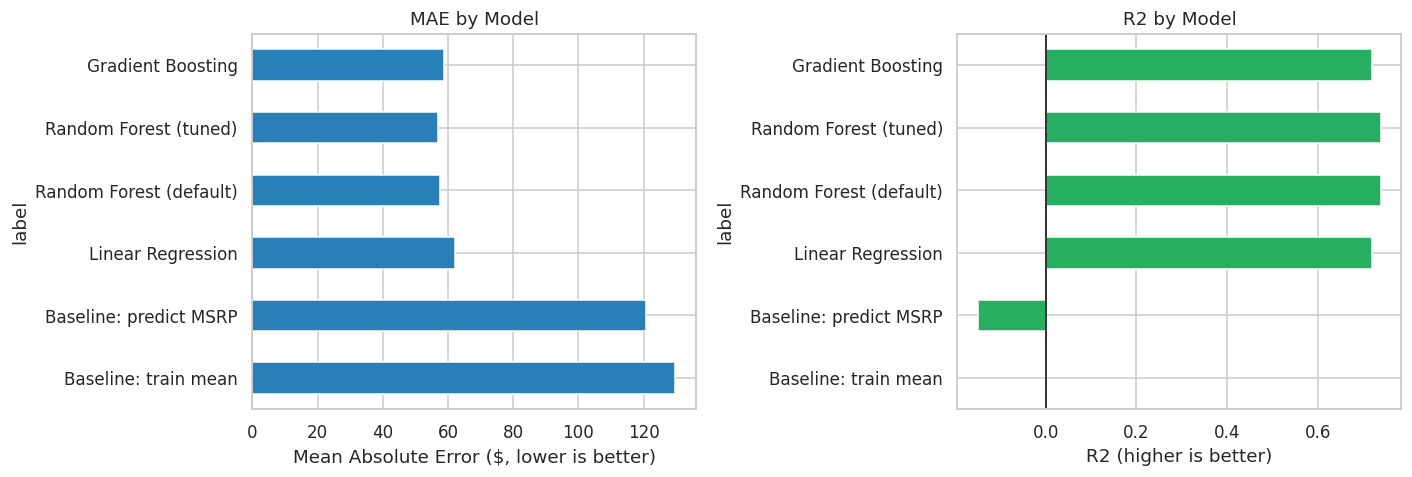

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

results_df["MAE"].plot(kind="barh", ax=axes[0], color="#2980b9")
axes[0].set_xlabel("Mean Absolute Error ($, lower is better)")
axes[0].set_title("MAE by Model")

results_df["R2"].plot(kind="barh", ax=axes[1], color="#27ae60")
axes[1].set_xlabel("R2 (higher is better)")
axes[1].set_title("R2 by Model")
axes[1].axvline(0, color="black", linewidth=1)

plt.tight_layout()
plt.show()


**Takeaway:** tuning improved the Random Forest slightly on the actual test set — MAE $57.52 →
$56.90, with R² holding steady at 0.74. Gradient Boosting (MAE $58.75) sits between Linear Regression
(MAE $62.07 / R² 0.72) and the two Random Forest versions, but doesn't beat either — so among the models
tried, tuned Random Forest remains the best. All four trained models beat the naive baselines (MAE
$121–130, R² ≈ 0) by a wide margin.


## 9. Prediction Accuracy: Predicted vs. Actual


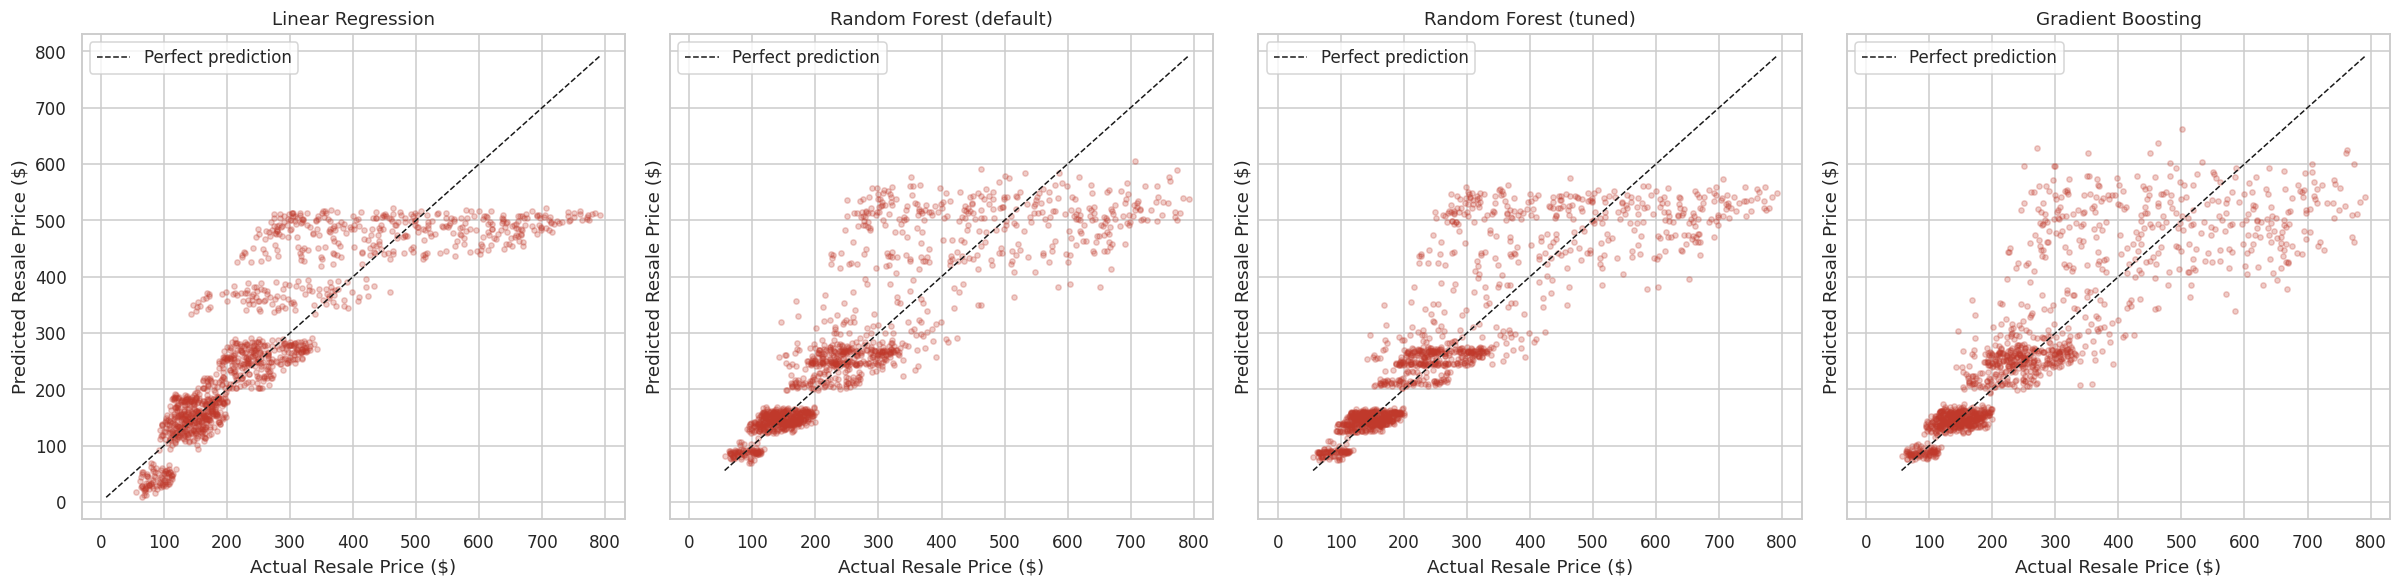

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5.5), sharex=True, sharey=True)

for ax, pred, title in zip(axes, [linear_pred, rf_pred, rf_tuned_pred, gb_pred],
                            ["Linear Regression", "Random Forest (default)", "Random Forest (tuned)",
                             "Gradient Boosting"]):
    ax.scatter(y_test, pred, alpha=0.25, s=12, color="#c0392b")
    lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
    ax.plot(lims, lims, "k--", linewidth=1, label="Perfect prediction")
    ax.set_xlabel("Actual Resale Price ($)")
    ax.set_ylabel("Predicted Resale Price ($)")
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()


**Takeaway:** all four models track actual price reasonably well in the sub-$350 range, where
most of the data sits, but **all four systematically under-predict the high-price tail** — for shoes
that actually sold above ~$400, predictions cluster around $450–550 instead of following the diagonal.
Tuning did not fix this, and neither does switching model families entirely — it's a data/feature
limitation (no feature flags "this is a rare, high-hype pair"), not something any of these models can
solve on their own. You can also see predictions forming distinct horizontal bands rather than a smooth
cloud across all three tree-based models; that's consistent with `Condition` (a 3-category feature)
doing most of the separating, which the feature importance charts below confirm directly.


## 10. Feature Importance

### 10.1 Random Forest (Tuned)

Which features is the tuned Random Forest actually leaning on? We check this against what the EDA
already told us to see whether the model "discovered" the same story.


In [15]:
feature_names = (
    list(rf_tuned_pipeline.named_steps["preprocess"].named_transformers_["cat"].get_feature_names_out(FEATURES_CAT))
    + FEATURES_NUM
)
importances = rf_tuned_pipeline.named_steps["model"].feature_importances_

# Group one-hot columns back up to their original feature for a readable chart
importance_df = pd.DataFrame({"feature": feature_names, "importance": importances})
def base_feature(name):
    for c in FEATURES_CAT:
        if name.startswith(c + "_"):
            return c
    return name
importance_df["group"] = importance_df["feature"].apply(base_feature)
grouped_importance = importance_df.groupby("group")["importance"].sum().sort_values(ascending=False)
grouped_importance


group
Condition           0.828544
Retail_Price_USD    0.121458
Shoe_Model          0.033336
Colorway            0.006612
Sales_Channel       0.006084
Sale_Quarter        0.002767
Sale_Year           0.001198
Name: importance, dtype: float64

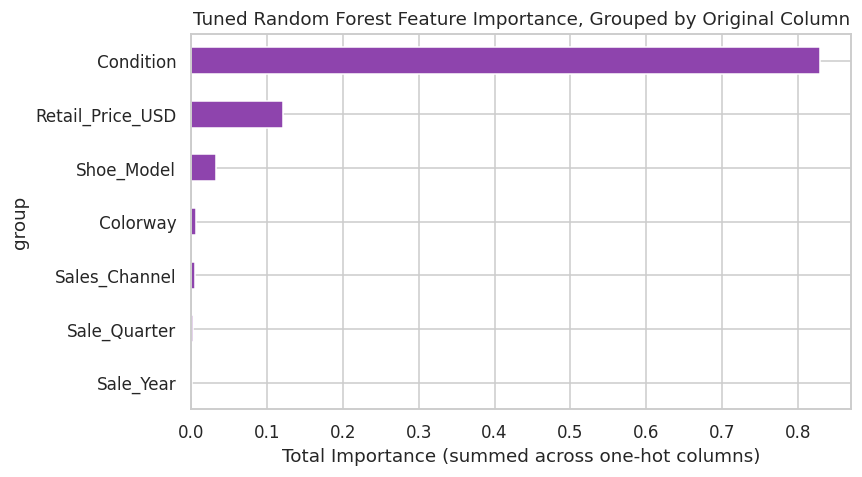

In [16]:
fig, ax = plt.subplots(figsize=(8, 4.5))
grouped_importance.plot(kind="barh", ax=ax, color="#8e44ad")
ax.invert_yaxis()
ax.set_xlabel("Total Importance (summed across one-hot columns)")
ax.set_title("Tuned Random Forest Feature Importance, Grouped by Original Column")
plt.tight_layout()
plt.show()


### 10.2 Gradient Boosting (Permutation Importance)

`HistGradientBoostingRegressor` doesn't expose a built-in `feature_importances_` the way Random Forest
does, so we use **permutation importance** instead: shuffle one feature's values at a time in the test
set and measure how much worse the model's error gets. A feature the model actually relies on will make
the error jump when scrambled; a feature it ignores won't move the error much either way. This is a
different measurement method than Random Forest's built-in importances above, so the two charts aren't
directly comparable number-for-number — but they can still be compared for *ranking*, which is what
we care about here.


In [17]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    gb_pipeline, X_test, y_test, n_repeats=10, random_state=RANDOM_STATE,
    n_jobs=4, scoring="neg_mean_absolute_error"
)
gb_importance = pd.Series(perm_result.importances_mean, index=X_test.columns).sort_values(ascending=False)
gb_importance.round(2)


Condition           103.46
Retail_Price_USD     16.93
Shoe_Model            3.67
Sale_Quarter          0.00
Sale_Year             0.00
Sales_Channel        -0.16
Colorway             -0.66
dtype: float64

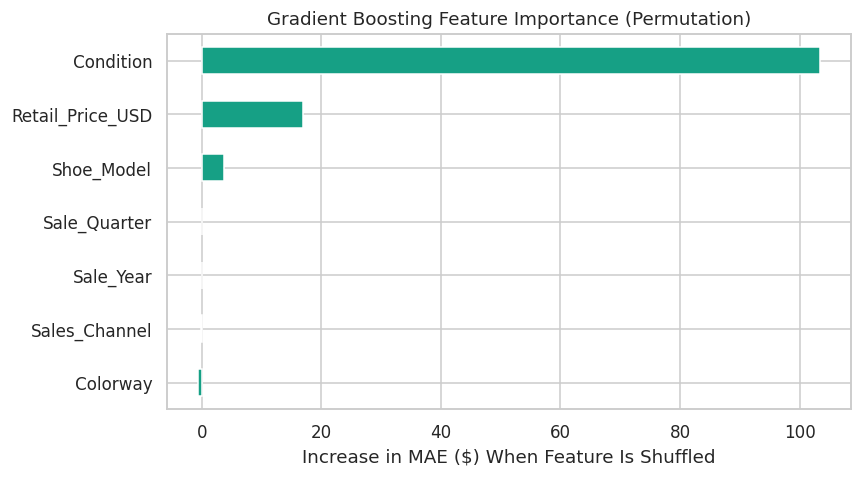

In [18]:
fig, ax = plt.subplots(figsize=(8, 4.5))
gb_importance.plot(kind="barh", ax=ax, color="#16a085")
ax.invert_yaxis()
ax.set_xlabel("Increase in MAE ($) When Feature Is Shuffled")
ax.set_title("Gradient Boosting Feature Importance (Permutation)")
plt.tight_layout()
plt.show()


**Takeaway:** despite using a completely different importance method, Gradient Boosting tells the
exact same story as Random Forest: shuffling `Condition` alone makes the error jump by roughly $100+,
dwarfing every other feature. `Retail_Price_USD` is a distant second, and everything else (`Shoe_Model`,
`Colorway`, `Sales_Channel`, the time features) barely moves the error at all — a couple even show a
small *negative* number, meaning shuffling them didn't hurt (or very slightly helped) the model, which
is normal noise for a feature the model wasn't relying on anyway. Two different model families, two
different importance methods, same conclusion: `Condition` is doing almost all of the work.


## 11. Summary

- **Tuning found shallower, more regularized trees than the hand-picked defaults**: the best
  cross-validated combination was `max_depth=6`, `min_samples_leaf=5`, `n_estimators=200` (vs. the
  original `max_depth=8`, `n_estimators=300`), with a cross-validated training MAE of $51.44.
- **On the held-out 2025 test set, tuning gave a small, real improvement**: MAE went from **$57.52**
  (default Random Forest) to **$56.90** (tuned), with R² essentially unchanged at **0.74** for both.
  That's consistent with the earlier finding that the untuned defaults were already reasonable —
  tuning refined the model rather than transforming it.
- **Gradient Boosting (default settings) lands between Linear Regression and Random Forest**: MAE
  $58.75, beating Linear Regression ($62.07) but not quite matching either Random Forest version
  (~$57). Boosting didn't add anything beyond what Random Forest already captures in this dataset.
- **All four trained models comfortably beat the naive baselines** (MAE $121–130, R² ≈ 0): Linear
  Regression reaches MAE $62.07 / R² 0.72, Gradient Boosting reaches MAE $58.75, and both Random Forest
  versions reach MAE ~$57 / R² 0.74.
- **`Condition` still overwhelmingly dominates feature importance (83% for the tuned Random Forest)**,
  with `Retail_Price_USD` a distant second (12%). Gradient Boosting's permutation importance — a
  completely different measurement method — confirms the same ranking: `Condition` causes by far the
  largest jump in error when shuffled, everything else barely moves it.
- **All four models struggle on the high-price tail** — for shoes that resold above ~$400, predictions
  cluster around $450–550 rather than tracking actual price. Neither tuning nor switching model
  families fixes this; it's a data/feature limitation (no feature flags "rare, high-hype pair"), not
  something hyperparameter search or model choice can solve.
- **Time features contributed almost nothing** (`Sale_Year` + `Sale_Quarter` <1% combined importance
  for Random Forest), consistent with the EDA finding that there's no real trend across 2023–2025 in
  this dataset.

## Next Steps

Possible extensions beyond this notebook:
- Tune Gradient Boosting's hyperparameters (learning rate, number of iterations, tree depth) the way we
  tuned Random Forest — unlikely to overtake Random Forest given how dominant `Condition` is, but worth
  confirming the same way tuning gave Random Forest a small real gain
- Since the high-price tail is where all models struggle most, consider a model trained separately on
  high-value listings, or a log-transformed target to reduce the influence of the long right tail
- Widen the hyperparameter grid (more values per parameter, or `RandomizedSearchCV` for a larger search
  space) — this notebook used a modest grid to keep runtime short, and it already found a small real
  improvement, so a wider search might find a bit more

## 12. Interactive Price Predictor

The cell below builds a live widget using the actual `rf_tuned_pipeline` already trained above — pick a
Shoe Model, Colorway, Condition, and Sales Channel, and it predicts a resale price on the spot using the
real model, not a lookup table. It also warns if you enter a retail price outside what that specific
model actually sold for in the training data (e.g. Air Jordan 1 Low never appears above $140) — Random
Forests don't extrapolate meaningfully past what they've seen, so a wildly out-of-range input would
otherwise silently produce a meaningless number.

**This cell requires `ipywidgets`** (`pip install ipywidgets`) and a live Jupyter session — unlike the
charts elsewhere in this notebook, an interactive widget can't be pre-rendered into a static file, so
GitHub's notebook viewer will show this cell's code but not a working widget. Run it locally, in
JupyterLab, or in Colab to actually use it. A fully static, no-Python-required version of this same tool
(running the identical tuned Random Forest, exported to JavaScript) is also included in this project as
[`jordan_price_predictor.html`](jordan_price_predictor.html).


In [ ]:
import ipywidgets as widgets
from IPython.display import display

model_dropdown = widgets.Dropdown(options=sorted(df["Shoe_Model"].unique()), description="Model:")
colorway_dropdown = widgets.Dropdown(options=sorted(df["Colorway"].unique()), description="Colorway:")
condition_dropdown = widgets.Dropdown(options=sorted(df["Condition"].unique()), description="Condition:")
channel_dropdown = widgets.Dropdown(options=sorted(df["Sales_Channel"].unique()), description="Channel:")
retail_input = widgets.IntSlider(value=200, min=50, max=500, step=5, description="Retail $:")
output = widgets.Output()

# Each model was only ever sold at a narrow range of retail prices in this data (e.g. Air Jordan 1 Low
# is $110-$140, Air Jordan 11 Retro is $225-$230) — the Random Forest can't meaningfully extrapolate
# beyond what it saw in training, so we warn rather than silently returning a number for an unrealistic
# combination.
retail_ranges = df.groupby("Shoe_Model")["Retail_Price_USD"].agg(["min", "max"])

def predict_price(*args):
    model = model_dropdown.value
    retail = retail_input.value
    row = pd.DataFrame([{
        "Shoe_Model": model,
        "Colorway": colorway_dropdown.value,
        "Condition": condition_dropdown.value,
        "Sales_Channel": channel_dropdown.value,
        "Retail_Price_USD": retail,
        "Sale_Year": 2025,
        "Sale_Quarter": 3,
    }])
    pred = rf_tuned_pipeline.predict(row)[0]
    margin_pct = (pred - retail) / retail * 100 if retail else 0
    range_min, range_max = retail_ranges.loc[model, "min"], retail_ranges.loc[model, "max"]
    with output:
        output.clear_output()
        if retail < range_min or retail > range_max:
            print(f"WARNING: {model} only ever sold for ${range_min}-${range_max} retail in this "
                  f"data. ${retail} is outside that range, so this prediction is unreliable "
                  f"extrapolation, not a value the model actually learned from.")
        else:
            print(f"Typical retail range for {model}: ${range_min}-${range_max}")
        print(f"Predicted resale price: ${pred:,.2f}")
        print(f"Estimated margin: {margin_pct:+.1f}% vs. retail (${retail})")
        print(f"Model's typical error size (MAE on 2025 test data): +/- $57 "
              f"(not a formal confidence interval, just the average size of its mistakes)")

for w in [model_dropdown, colorway_dropdown, condition_dropdown, channel_dropdown, retail_input]:
    w.observe(predict_price, names="value")

display(model_dropdown, colorway_dropdown, condition_dropdown, channel_dropdown, retail_input, output)
predict_price()
